# Regime-Stratified Sensitivity Analysis — Level 5L6

Sensitivity of the L5L6 model **conditioned on the rate-limiting regime**
(surface- / oxide- / metal-limited), where **regime = argmax of the flux-weighted
resistance fractions** (`frac_surface`, `frac_oxide`, `frac_metal`).

**Method (Option A — targeted per-regime sampling):**
- **Phase 1:** one LHS scan per regime over a regime-favouring *preset* → label by
  argmax → keep the in-regime cluster.
- **Phase 2 Route B (primary):** given-data **PAWN** + **Borgonovo-δ** on the *true*
  cluster — valid on scattered points, zero extra model evaluations.
- **Phase 2 Route A (secondary):** **accept-and-report** Saltelli S1/ST over each
  regime's top-k percentile **sub-box** (off-regime contamination reported).
- Heavy-tailed metrics (`flux`, `permeability`) analysed on **log10**; `theta` linear.

**Data is cached to CSV** (see `RESULTS_DIR`): the first run saves all model
evaluations and result tables; later runs **reload** them and skip the expensive
model calls. Set `FORCE_RECOMPUTE = True` (or delete `RESULTS_DIR`) to regenerate.

See [docs/regime_sensitivity_workflow.md](../docs/regime_sensitivity_workflow.md).
Run with the **`mace_env`** kernel.

In [30]:
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

# repo root on path (mirrors the other notebooks)
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [31]:
import validation.sensitivity_level1 as sens
importlib.reload(sens)
from validation.sensitivity_level1 import (
    SUGGESTED_RANGES_LEVEL5L6, REGIME_PRESETS, DEFAULT_N_PER_REGIME, REGIME_SA_METRICS,
    run_targeted_regime_scans, load_regime_scans, plot_regime_exploration,
    morris_screen_global, rank_and_select_top_k,
    givendata_sensitivity_by_regime, summarize_givendata, plot_givendata_results,
    sobol_regime_subbox, plot_sobol_results, contamination_summary, summarize_route_a,
    regime_comparison_matrix, plot_regime_comparison_heatmap, plot_route_a
)
PARAMS = list(SUGGESTED_RANGES_LEVEL5L6.keys())
print(f"{len(PARAMS)} parameters; regime presets: {list(REGIME_PRESETS)}")

36 parameters; regime presets: ['metal', 'surface', 'oxide']


In [32]:
# === Run configuration (scale these up for a production run) ==================
SEED            = 42
N_PER_REGIME    = {'metal': 1000, 'surface': 2500, 'oxide': 5000}  # LHS draws per preset
MORRIS_TRAJ     = 256        # global Morris screen trajectories
SOBOL_N         = 256        # Route A Saltelli base samples (per regime)
TOP_K           = 8          # params kept for ranking / Route A sub-box
METRICS         = ['flux', 'permeability', 'theta']

# === Data caching =============================================================
RESULTS_DIR     = "sa_results"     # all CSV outputs live here
FORCE_RECOMPUTE = False            # True (or delete RESULTS_DIR) to recompute from scratch
SCAN_DIR        = os.path.join(RESULTS_DIR, "scans")
os.makedirs(SCAN_DIR, exist_ok=True)

def cache_path(name):
    """Path under RESULTS_DIR; removed first if FORCE_RECOMPUTE so the step recomputes."""
    p = os.path.join(RESULTS_DIR, name)
    if FORCE_RECOMPUTE and os.path.exists(p):
        os.remove(p)
    return p
print("results dir:", os.path.abspath(RESULTS_DIR), "| FORCE_RECOMPUTE =", FORCE_RECOMPUTE)

results dir: /Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/Application/sa_results | FORCE_RECOMPUTE = False


## Phase 1 — Targeted per-regime scans (cached)

If the scan CSVs already exist they are reloaded (no model calls); otherwise the
scans run and are saved to `RESULTS_DIR/scans/scan_<regime>.csv`.

In [9]:
scan_files = [os.path.join(SCAN_DIR, f"scan_{r}.csv") for r in ('metal', 'surface', 'oxide')]

if (not FORCE_RECOMPUTE) and all(os.path.exists(p) for p in scan_files):
    print("Loading cached scans from", SCAN_DIR)
    clusters, scans, master = load_regime_scans(SCAN_DIR)
    yields = {r: clusters[r].shape[0] / scans[r].shape[0] for r in clusters}
else:
    clusters, scans, master, yields = run_targeted_regime_scans(
        N_per_regime=N_PER_REGIME, seed=SEED, save_dir=SCAN_DIR, verbose=True)

print("\nCluster sizes:", {k: len(v) for k, v in clusters.items()})
print("Yields:", {k: f"{v*100:.1f}%" for k, v in yields.items()})

# Save the combined in-regime table
master.to_csv(os.path.join(RESULTS_DIR, "master_clusters.csv"), index=False)
print("\nMedian outputs by regime:")
print(master.groupby('regime')[['flux', 'permeability', 'theta']].median().to_string())

Loading cached scans from sa_results/scans

Cluster sizes: {'metal': 813, 'surface': 714, 'oxide': 3725}
Yields: {'metal': '81.3%', 'surface': '28.6%', 'oxide': '74.5%'}

Median outputs by regime:
                 flux  permeability     theta
regime                                       
metal    7.941383e-06  1.365011e-14  0.359885
oxide    2.707979e-08  4.282783e-17  0.370475
surface  3.354897e-09  1.120678e-13  0.000028


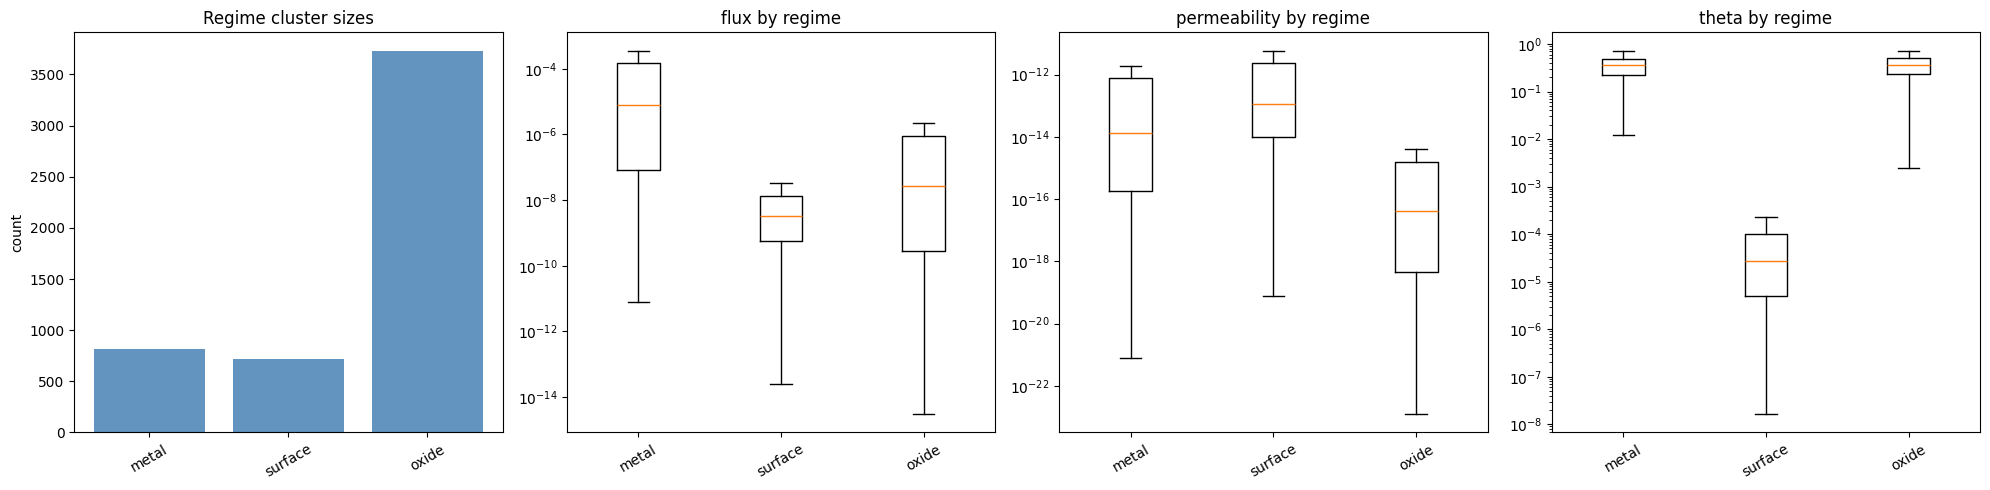


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting  metal  mixed  oxide  surface
regime                                            
metal                  2327   1234     67        9
oxide                     1    784   3364        0
surface                  39    287      1      387


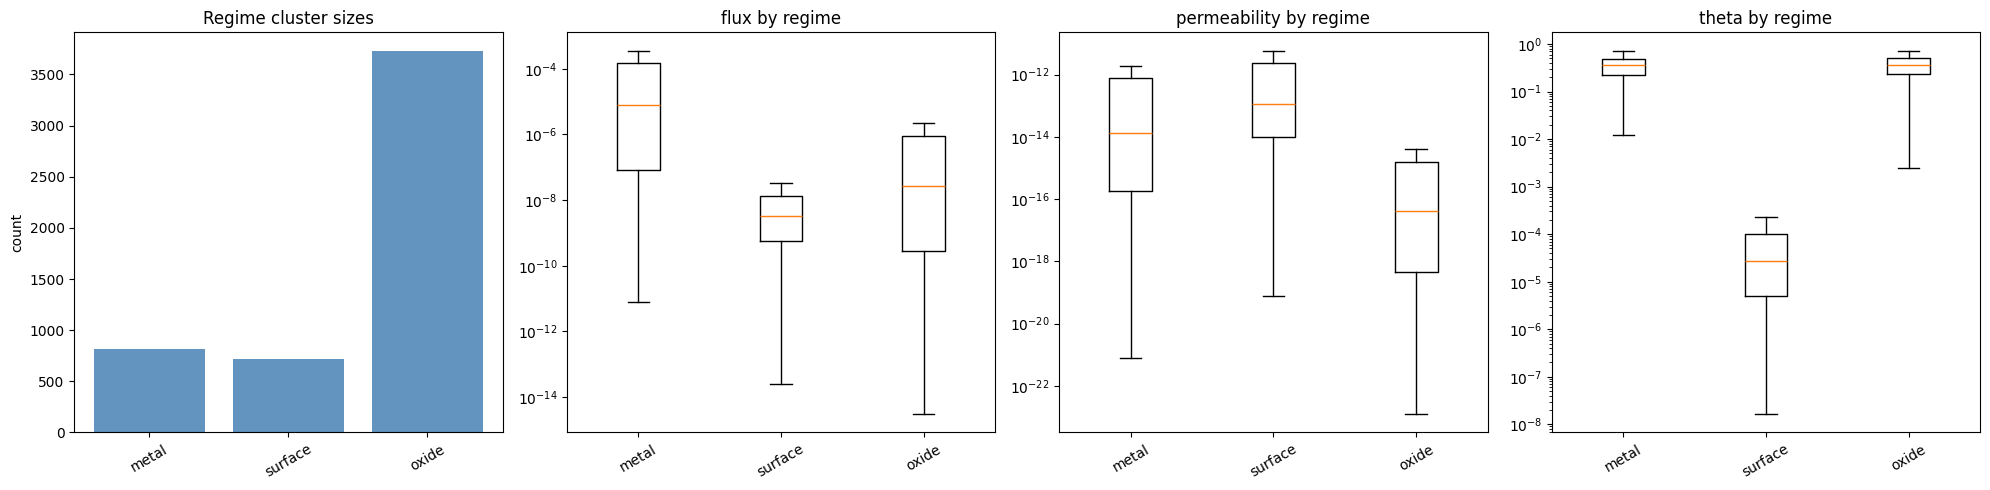

In [10]:
full_scan = pd.concat(scans.values(), ignore_index=True)
plot_regime_exploration(clusters, output_metrics=('flux', 'permeability', 'theta'),
                        scan_df=full_scan)

## Phase 1 (screen) — Global Morris over all 40 params (cached)

Evaluations cached to `RESULTS_DIR/morris_evals.csv`; the ranking is saved to
`RESULTS_DIR/morris_ranking.csv`.

In [11]:
screen = morris_screen_global(SUGGESTED_RANGES_LEVEL5L6, output_metrics=METRICS,
                              N_trajectories=MORRIS_TRAJ, seed=SEED,
                              cache_csv=cache_path("morris_evals.csv"))
df_rank, top_k_global = rank_and_select_top_k(screen, output_metrics=METRICS, k=TOP_K)
df_rank.to_csv(os.path.join(RESULTS_DIR, "morris_ranking.csv"), index=False)

  [cache] loaded Morris evals from sa_results/morris_evals.csv (9472 rows)

  Global Morris ranking (μ* normalised & averaged):
             Parameter  mu_star_flux  mu_star_permeability  mu_star_theta  Avg_Importance
           temperature  6.228831e+00          7.146793e+00   1.852422e-01    8.499584e-01
            P_upstream  5.398354e+00          5.324238e-01   3.278142e-01    6.380861e-01
              K_eq_ref  4.724532e-01          1.511791e-01   3.368804e-01    3.656676e-01
                 D_ref  2.607649e+00          8.038662e-01   2.127048e-02    1.980869e-01
              H_sol_ox  7.411367e-01          2.837531e+00   2.127509e-02    1.930579e-01
                  H_eq  5.660825e-02          2.560946e-02   1.858669e-01    1.881337e-01
              D_ox_ref  6.971065e-01          2.732743e+00   8.455279e-03    1.731294e-01
               K_s_ref  2.017018e+00          5.373221e-01   1.698005e-02    1.498024e-01
            k_diss_ref  4.828693e-01          1.403927e-01   3

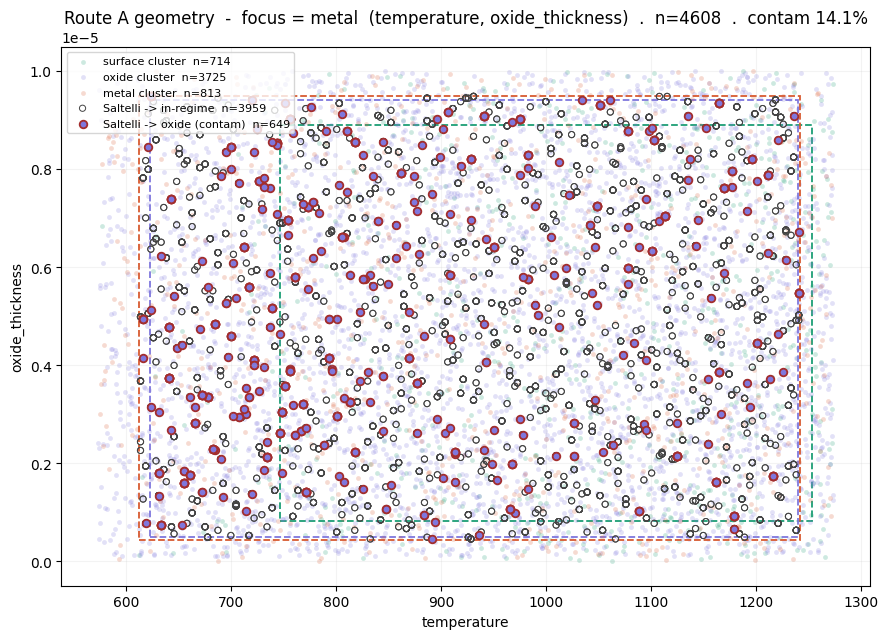

wrote 24 frames to sa_results/anim/metal
stitch:  ffmpeg -framerate 8 -i sa_results/anim/metal/frame_%05d.png anim_metal.gif


'sa_results/anim/metal'

In [33]:
# Route A view  —  pass route_a so the sub-box is exact
plot_route_a(clusters, axes=regime_topk('metal')[:2],
             focus='metal', route_a=route_a)

# Animation
plot_route_a(clusters, axes=regime_topk('metal')[:2],
             focus='metal', route_a=route_a,
             animate=True, step=200)

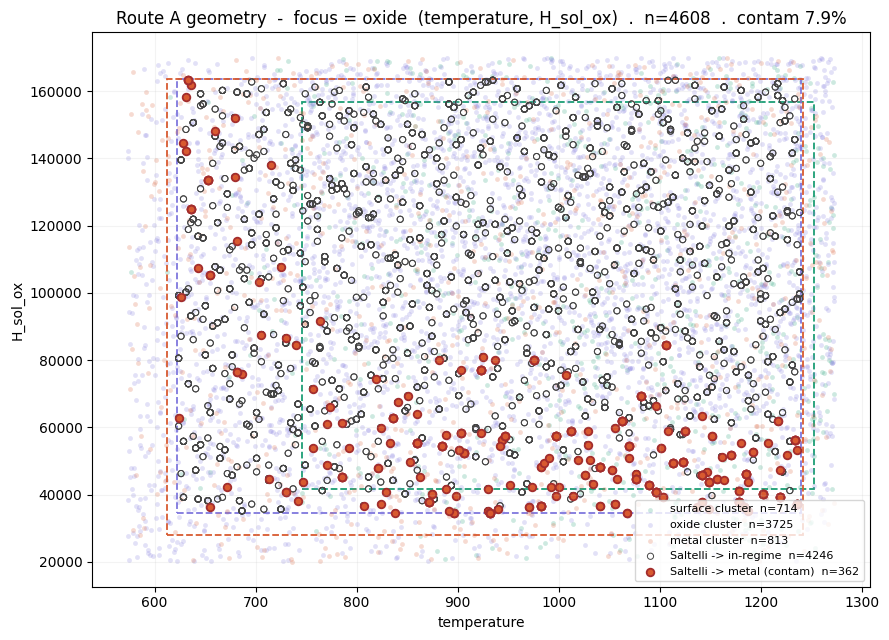

wrote 24 frames to sa_results/anim/oxide
stitch:  ffmpeg -framerate 8 -i sa_results/anim/oxide/frame_%05d.png anim_oxide.gif


'sa_results/anim/oxide'

In [34]:
# Route A view  —  pass route_a so the sub-box is exact
plot_route_a(clusters, axes=regime_topk('oxide')[:2],
             focus='oxide', route_a=route_a)

# Animation
plot_route_a(clusters, axes=regime_topk('oxide')[:2],
             focus='oxide', route_a=route_a,
             animate=True, step=200)

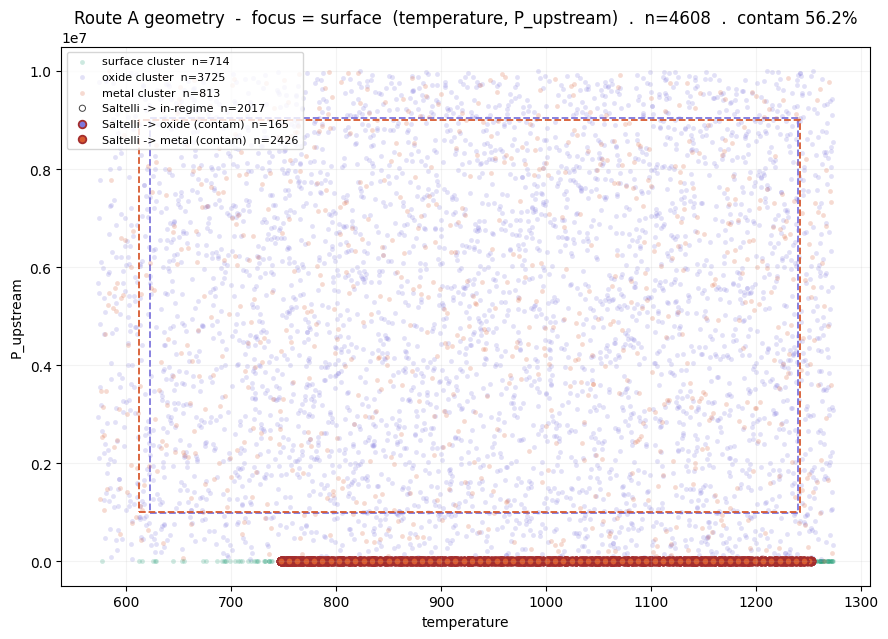

wrote 24 frames to sa_results/anim/surface
stitch:  ffmpeg -framerate 8 -i sa_results/anim/surface/frame_%05d.png anim_surface.gif


'sa_results/anim/surface'

In [35]:
# Route A view  —  pass route_a so the sub-box is exact
plot_route_a(clusters, axes=regime_topk('surface')[:2],
             focus='surface', route_a=route_a)

# Animation
plot_route_a(clusters, axes=regime_topk('surface')[:2],
             focus='surface', route_a=route_a,
             animate=True, step=200)

## Phase 2 — Route B (PRIMARY): given-data PAWN + δ on the true clusters

Zero extra model evaluations. Tidy results saved to `RESULTS_DIR/routeB_givendata.csv`.

In [15]:
gd = givendata_sensitivity_by_regime(clusters, PARAMS, output_metrics=METRICS,
                                     methods=('pawn', 'delta'), seed=SEED)
tidy = summarize_givendata(gd, PARAMS)
tidy.to_csv(os.path.join(RESULTS_DIR, "routeB_givendata.csv"), index=False)

for reg in clusters:
    sub = tidy[(tidy.regime == reg) & (tidy.metric == 'flux')].nlargest(8, 'delta')
    print(f"\n[{reg}] top-8 δ drivers of log10(flux):")
    print(sub[['parameter', 'delta', 'pawn_median', 'S1_givendata']].to_string(index=False))

  [metal/flux] n=  813  top-δ param: temperature
  [metal/permeability] n=  813  top-δ param: temperature
  [metal/theta] n=  813  top-δ param: P_upstream
  [surface/flux] n=  714  top-δ param: temperature
  [surface/permeability] n=  714  top-δ param: temperature
  [surface/theta] n=  714  top-δ param: P_upstream
  [oxide/flux] n= 3725  top-δ param: temperature
  [oxide/permeability] n= 3725  top-δ param: temperature
  [oxide/theta] n= 3725  top-δ param: P_upstream

[metal] top-8 δ drivers of log10(flux):
       parameter    delta  pawn_median  S1_givendata
     temperature 0.546366     0.478611      0.833331
 oxide_thickness 0.114296     0.088743      0.014462
 metal_thickness 0.113254     0.106123      0.018287
      k_diss_ref 0.107225     0.080999      0.010983
     trap_gb_N_T 0.098120     0.085167      0.009361
     f_gb_defect 0.096147     0.080219      0.014035
        H_sol_ox 0.091242     0.122933      0.036524
trap_carbide_N_T 0.091094     0.074753      0.013448

[surface] 

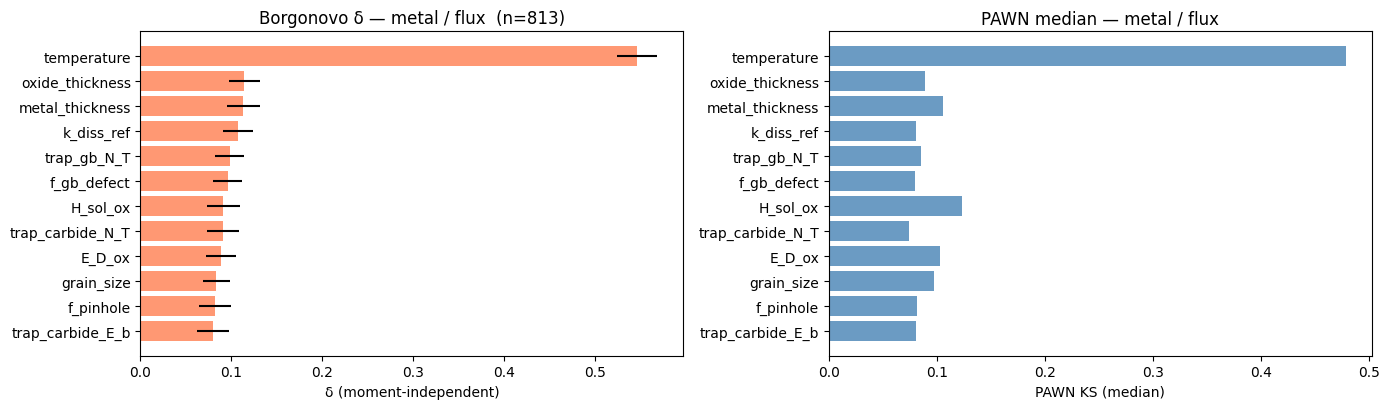

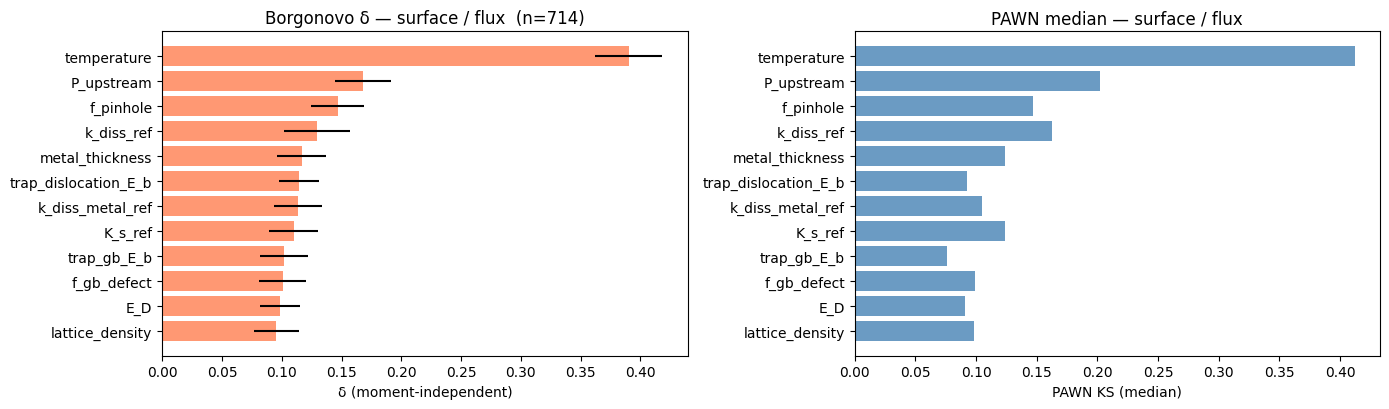

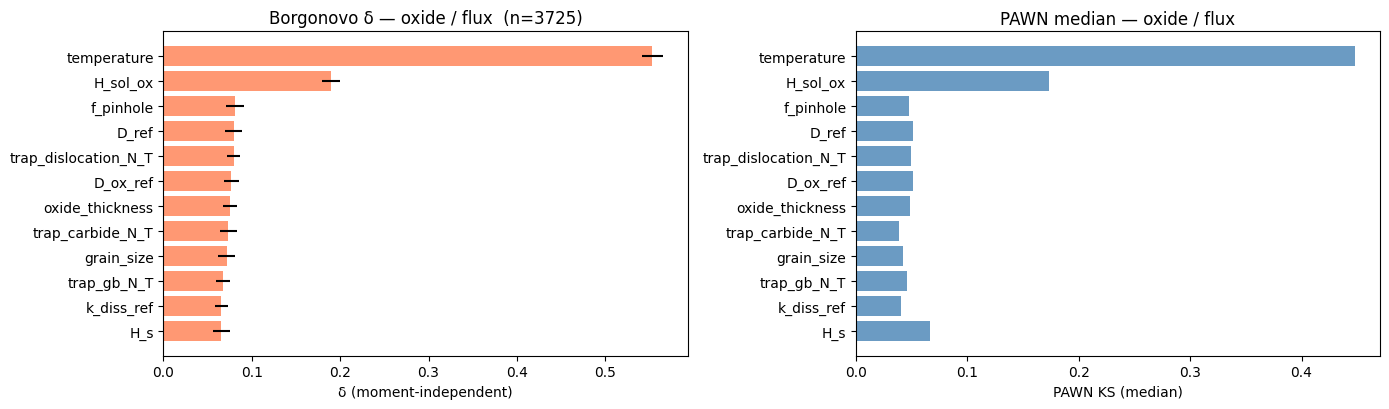

In [16]:
for reg in clusters:
    plot_givendata_results(gd, reg, 'flux', PARAMS, top_n=12)

## Phase 2 — Route A (SECONDARY): Saltelli over each regime's sub-box (cached)

Per-regime evaluations cached to `RESULTS_DIR/routeA_evals_<regime>.csv`; tidy S1/ST
saved to `RESULTS_DIR/routeA_sobol.csv` and contamination to `routeA_contamination.csv`.

In [17]:
def regime_topk(reg, k=TOP_K, metric='flux'):
    sub = tidy[(tidy.regime == reg) & (tidy.metric == metric)]
    return sub.nlargest(k, 'delta')['parameter'].tolist()

route_a = {}
for reg in clusters:
    tk = regime_topk(reg)
    print(f"\n=== Route A: {reg}  (top-{TOP_K} = {tk}) ===")
    route_a[reg] = sobol_regime_subbox(
        clusters[reg], tk, reg, output_metrics=METRICS,
        N=SOBOL_N, seed=SEED, fallback_ranges=REGIME_PRESETS[reg],
        cache_csv=cache_path(f"routeA_evals_{reg}.csv"), verbose=True)

summarize_route_a(route_a, PARAMS).to_csv(os.path.join(RESULTS_DIR, "routeA_sobol.csv"), index=False)
contamination_summary(route_a).to_csv(os.path.join(RESULTS_DIR, "routeA_contamination.csv"), index=False)
print("\nOff-regime contamination summary:")
print(contamination_summary(route_a).to_string(index=False))


=== Route A: metal  (top-8 = ['temperature', 'oxide_thickness', 'metal_thickness', 'k_diss_ref', 'trap_gb_N_T', 'f_gb_defect', 'H_sol_ox', 'trap_carbide_N_T']) ===
  [cache] loaded Route-A evals ('metal') from sa_results/routeA_evals_metal.csv (4608 rows)
  off-regime contamination: 14.1%  (in-regime 3959/4608)

=== Route A: surface  (top-8 = ['temperature', 'P_upstream', 'f_pinhole', 'k_diss_ref', 'metal_thickness', 'trap_dislocation_E_b', 'k_diss_metal_ref', 'K_s_ref']) ===
  [cache] loaded Route-A evals ('surface') from sa_results/routeA_evals_surface.csv (4608 rows)
  off-regime contamination: 56.2%  (in-regime 2017/4608)

=== Route A: oxide  (top-8 = ['temperature', 'H_sol_ox', 'f_pinhole', 'D_ref', 'trap_dislocation_N_T', 'D_ox_ref', 'oxide_thickness', 'trap_carbide_N_T']) ===
  [cache] loaded Route-A evals ('oxide') from sa_results/routeA_evals_oxide.csv (4608 rows)
  off-regime contamination: 7.9%  (in-regime 4246/4608)

Off-regime contamination summary:
 regime    n  in_regim

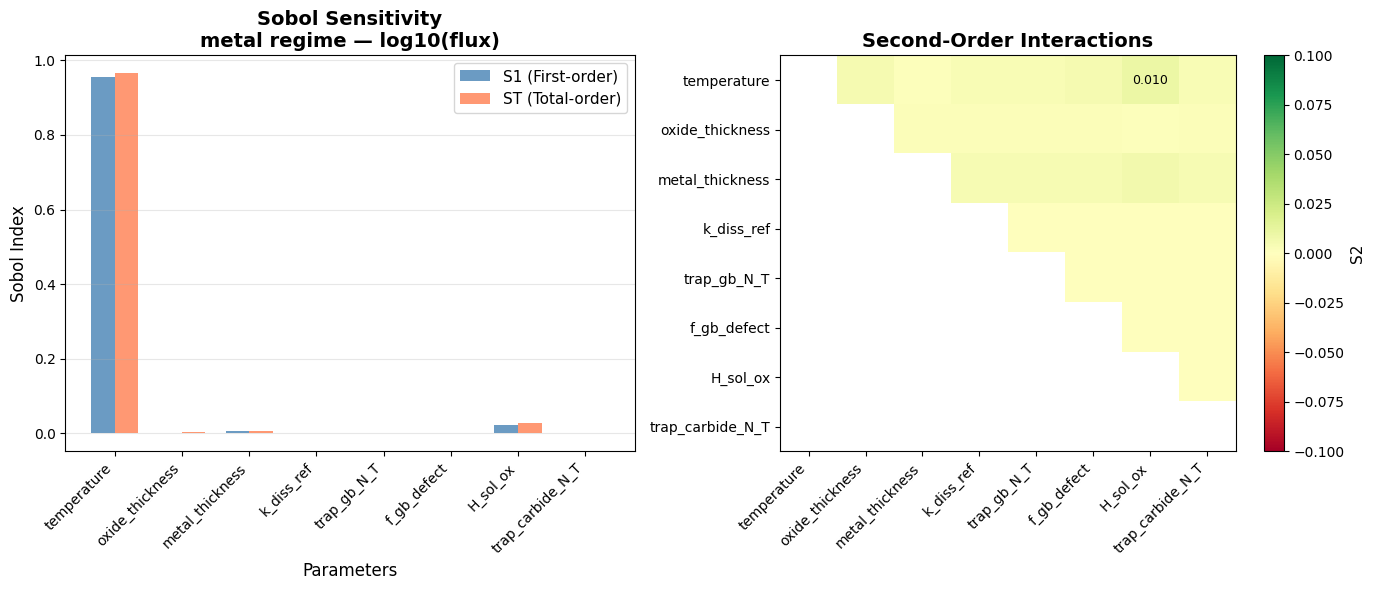


SOBOL SENSITIVITY RESULTS - metal regime — log10(flux)
       Parameter            S1      S1_conf           ST      ST_conf  Interactions
     temperature  9.557382e-01 1.400154e-01 9.651135e-01 1.138686e-01  9.375278e-03
 oxide_thickness  1.894504e-03 1.217020e-02 4.768034e-03 9.605738e-04  2.873529e-03
 metal_thickness  5.437442e-03 1.409420e-02 6.996017e-03 1.578642e-03  1.558575e-03
      k_diss_ref  3.070600e-06 1.614770e-05 8.706739e-09 7.039352e-09 -3.061893e-06
     trap_gb_N_T  3.968935e-15 1.501682e-14 5.203892e-27 1.152529e-27 -3.968935e-15
     f_gb_defect  2.281566e-04 3.410316e-03 3.200875e-04 8.349954e-05  9.193081e-05
        H_sol_ox  2.113920e-02 2.684697e-02 2.656428e-02 7.319120e-03  5.425082e-03
trap_carbide_N_T -3.278240e-05 5.158324e-04 8.747464e-06 2.066281e-06  4.152987e-05

Interpretation:
  S1   : First-order effect (direct influence)
  ST   : Total-order effect (direct + interactions)
  ST-S1: Pure interaction effects

Top 3 Most Influential Parameters:
  

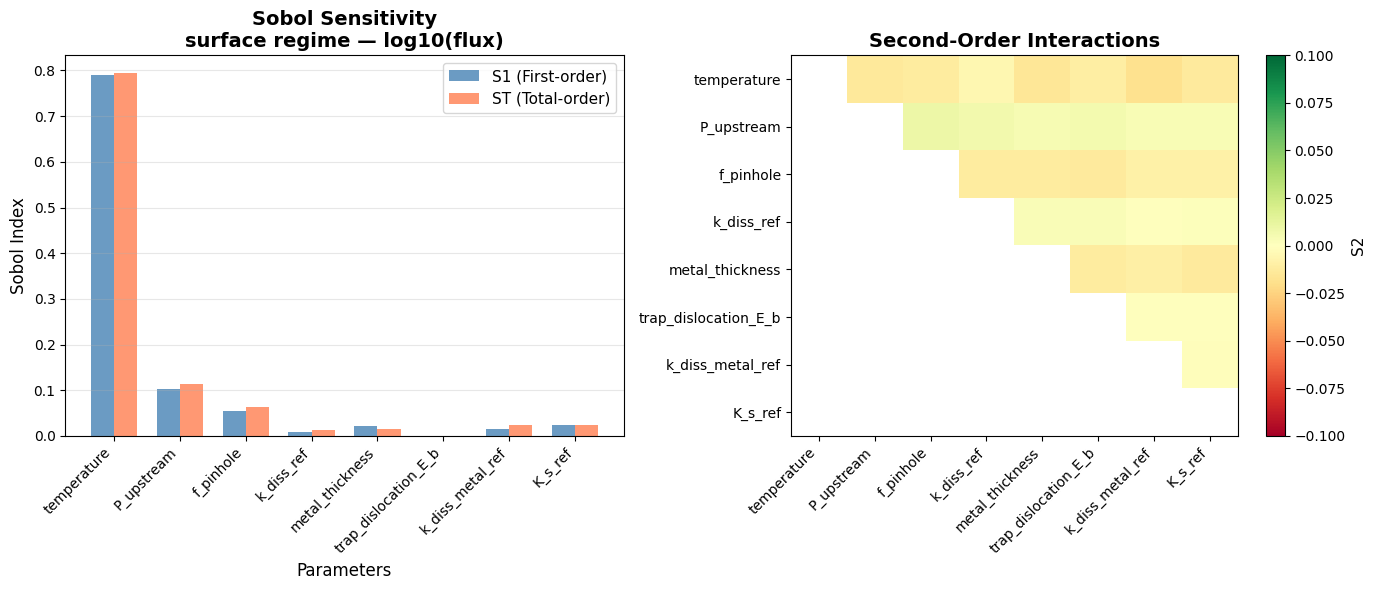


SOBOL SENSITIVITY RESULTS - surface regime — log10(flux)
           Parameter           S1      S1_conf           ST      ST_conf  Interactions
         temperature 7.892689e-01 1.434767e-01 7.934874e-01 1.125720e-01  4.218435e-03
          P_upstream 1.036103e-01 6.137606e-02 1.132881e-01 2.574646e-02  9.677810e-03
           f_pinhole 5.453298e-02 3.804590e-02 6.256420e-02 1.753765e-02  8.031214e-03
          k_diss_ref 7.726418e-03 2.035571e-02 1.201956e-02 3.941021e-03  4.293142e-03
     metal_thickness 2.163102e-02 2.112385e-02 1.418784e-02 3.546595e-03 -7.443174e-03
trap_dislocation_E_b 6.821594e-17 1.032777e-16 4.175233e-31 1.053634e-31 -6.821594e-17
    k_diss_metal_ref 1.606342e-02 2.733730e-02 2.486735e-02 9.910323e-03  8.803932e-03
             K_s_ref 2.448324e-02 2.456558e-02 2.504622e-02 6.154353e-03  5.629775e-04

Interpretation:
  S1   : First-order effect (direct influence)
  ST   : Total-order effect (direct + interactions)
  ST-S1: Pure interaction effects

Top 3 Mo

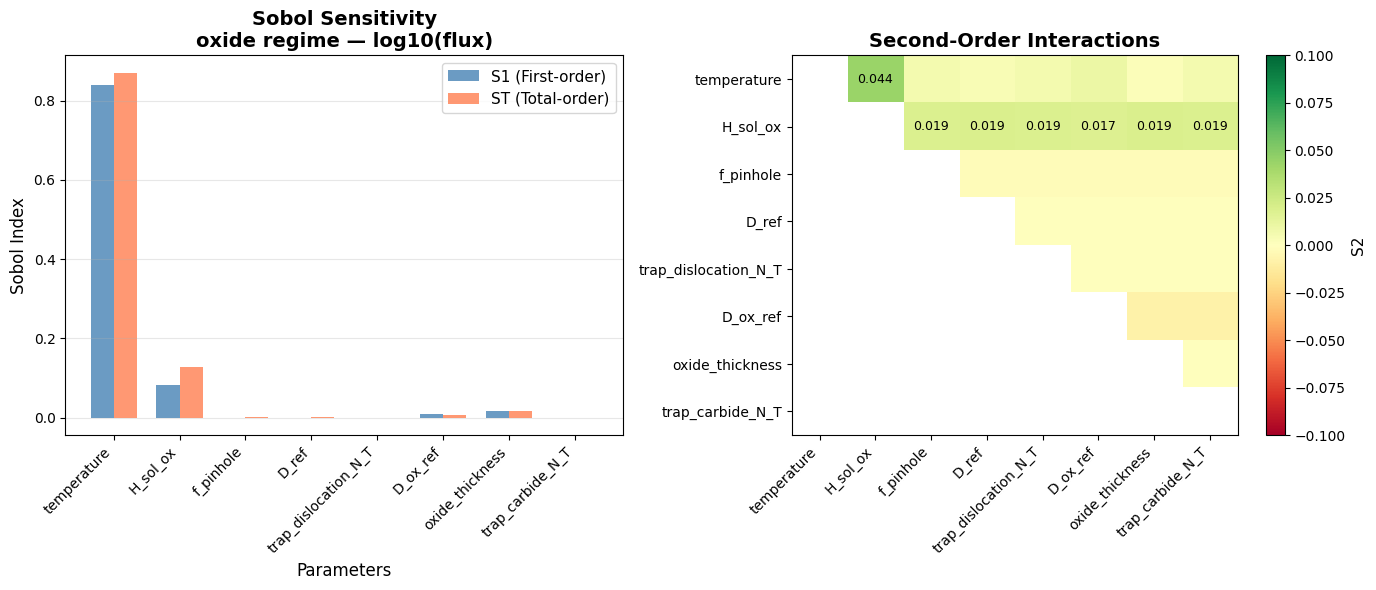


SOBOL SENSITIVITY RESULTS - oxide regime — log10(flux)
           Parameter            S1      S1_conf           ST      ST_conf  Interactions
         temperature  8.381342e-01 1.455632e-01 8.705897e-01 1.299786e-01  3.245549e-02
            H_sol_ox  8.247176e-02 6.379426e-02 1.288980e-01 2.853154e-02  4.642625e-02
           f_pinhole -3.386895e-04 5.854471e-03 9.507014e-04 5.461625e-04  1.289391e-03
               D_ref -5.012815e-04 3.839924e-03 5.381048e-04 2.428500e-04  1.039386e-03
trap_dislocation_N_T -3.873418e-18 3.461092e-17 2.704525e-32 1.266004e-32  3.873418e-18
            D_ox_ref  8.874192e-03 1.571823e-02 7.435768e-03 1.409745e-03 -1.438424e-03
     oxide_thickness  1.722351e-02 2.225120e-02 1.631917e-02 3.516223e-03 -9.043348e-04
    trap_carbide_N_T -1.216709e-04 1.288938e-04 6.449854e-07 3.515052e-07  1.223159e-04

Interpretation:
  S1   : First-order effect (direct influence)
  ST   : Total-order effect (direct + interactions)
  ST-S1: Pure interaction effects

T

In [26]:
for reg in clusters:
    entry = route_a[reg]['sobol']['flux']
    plot_sobol_results(entry['Si'], entry['problem'], f"{reg} regime — log10(flux)")

In [29]:
print("CSV cols:", pd.read_csv('sa_results/routeA_evals_metal.csv').columns.tolist())
print("route_a['metal'] keys:", list(route_a['metal'].keys()))
print("route_a['metal']['sobol']['flux'] keys:", list(route_a['metal']['sobol']['flux'].keys()))
# whichever one looks most promising — show me a small slice
for k, v in route_a['metal'].items():
    try:    print(f"  {k}: type={type(v).__name__}, shape={getattr(v,'shape',len(v))}")
    except: print(f"  {k}: type={type(v).__name__}")

CSV cols: ['temperature', 'oxide_thickness', 'metal_thickness', 'k_diss_ref', 'trap_gb_N_T', 'f_gb_defect', 'H_sol_ox', 'trap_carbide_N_T', 'Y_flux', 'Y_permeability', 'Y_theta', 'regime_hit']
route_a['metal'] keys: ['sobol', 'contamination', 'regime_counts', 'subbox', 'n']
route_a['metal']['sobol']['flux'] keys: ['Si', 'problem', 'log']
  sobol: type=dict, shape=3
  contamination: type=float
  regime_counts: type=dict, shape=2
  subbox: type=dict, shape=8
  n: type=int


In [28]:
# Animation  —  frames go to sa_results/anim/metal/
plot_route_a(clusters, axes=regime_topk('metal')[:2],
             focus='metal', animate=True, step=200)

KeyError: "None of [Index(['frac_surface', 'frac_oxide', 'frac_metal'], dtype='object')] are in the [columns]"

In [27]:
# Route A view  —  add Saltelli for one regime
plot_route_a(clusters, axes=regime_topk('metal')[:2], focus='metal')


KeyError: "None of [Index(['frac_surface', 'frac_oxide', 'frac_metal'], dtype='object')] are in the [columns]"

## Phase 3 — Cross-regime comparison (saved)

Comparison matrices saved to `RESULTS_DIR/compare_<index>_<metric>.csv`.

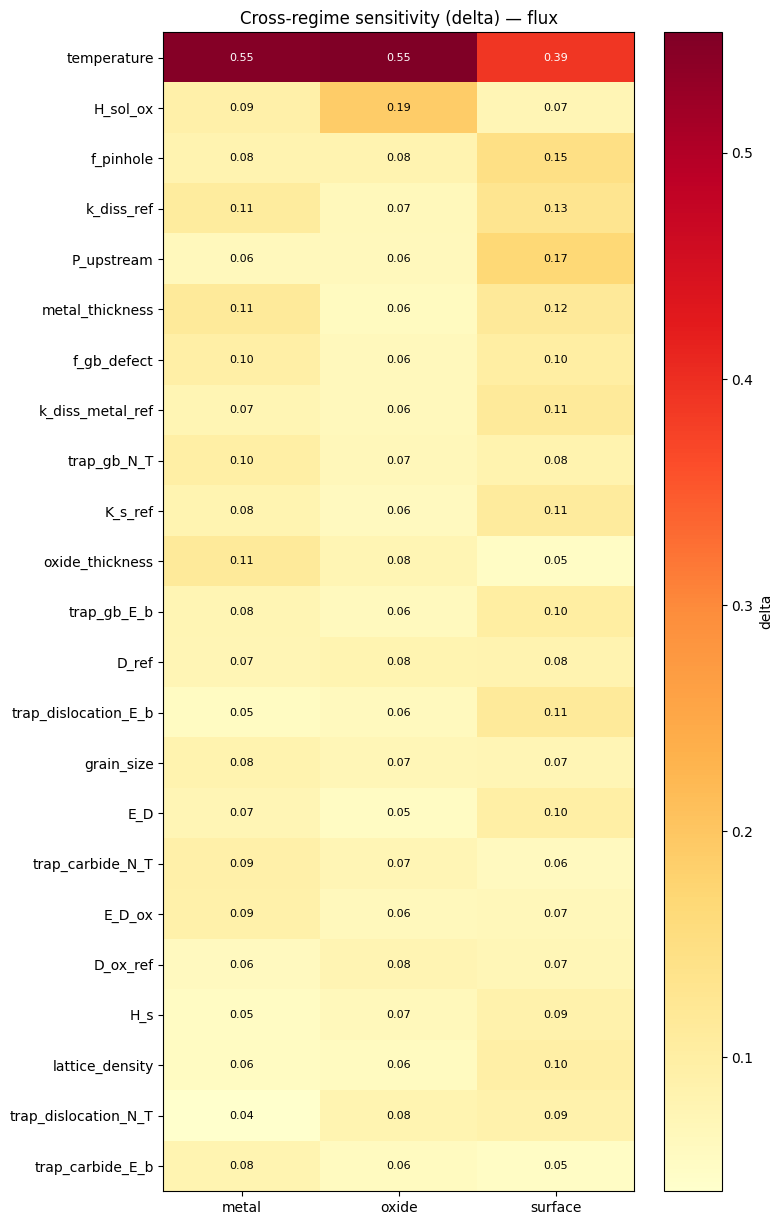

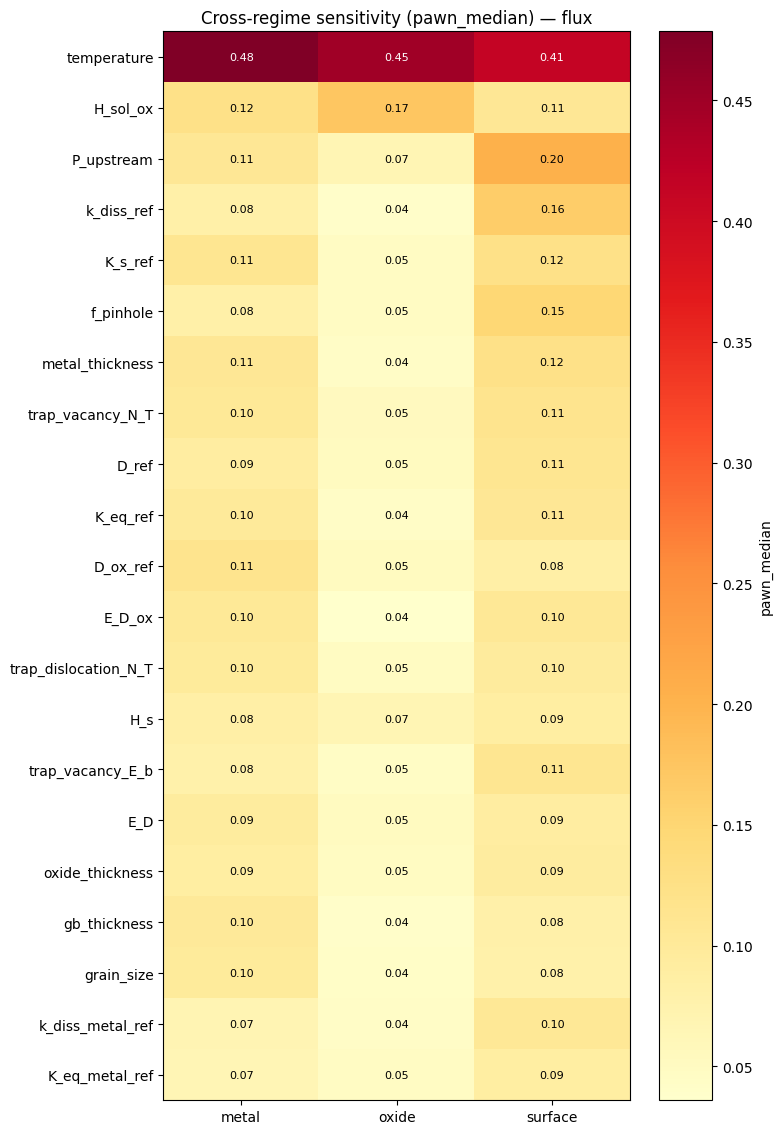

Cross-regime δ matrix (log10 flux):
regime                metal  oxide  surface
parameter                                  
temperature           0.546  0.553    0.390
H_sol_ox              0.091  0.189    0.075
f_pinhole             0.082  0.081    0.147
k_diss_ref            0.107  0.065    0.129
P_upstream            0.063  0.065    0.168
metal_thickness       0.113  0.057    0.117
f_gb_defect           0.096  0.064    0.101
k_diss_metal_ref      0.075  0.064    0.114
trap_gb_N_T           0.098  0.068    0.085
K_s_ref               0.079  0.060    0.110
oxide_thickness       0.114  0.075    0.051
trap_gb_E_b           0.077  0.062    0.102
D_ref                 0.073  0.080    0.082
trap_dislocation_E_b  0.055  0.061    0.115
grain_size            0.084  0.072    0.073
E_D                   0.073  0.053    0.098
trap_carbide_N_T      0.091  0.073    0.059
E_D_ox                0.089  0.064    0.068
D_ox_ref              0.059  0.077    0.073
H_s                   0.055  0.065    0.

In [22]:
plot_regime_comparison_heatmap(gd, 'flux', PARAMS, index='delta', top_union=12)
plot_regime_comparison_heatmap(gd, 'flux', PARAMS, index='pawn_median', top_union=12)

for idx in ('delta', 'pawn_median'):
    for met in METRICS:
        mat = regime_comparison_matrix(gd, met, PARAMS, index=idx, top_union=12)
        if not mat.empty:
            mat.to_csv(os.path.join(RESULTS_DIR, f"compare_{idx}_{met}.csv"))

print("Cross-regime δ matrix (log10 flux):")
print(regime_comparison_matrix(gd, 'flux', PARAMS, index='delta', top_union=12).round(3).to_string())

In [23]:
# Manifest of everything saved
import glob
print("Saved CSV files under", os.path.abspath(RESULTS_DIR), ":")
for f in sorted(glob.glob(os.path.join(RESULTS_DIR, "**", "*.csv"), recursive=True)):
    print("  ", os.path.relpath(f, RESULTS_DIR), f"({os.path.getsize(f)//1024} KB)")

Saved CSV files under /Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/Application/sa_results :
   compare_delta_flux.csv (1 KB)
   compare_delta_permeability.csv (1 KB)
   compare_delta_theta.csv (1 KB)
   compare_pawn_median_flux.csv (1 KB)
   compare_pawn_median_permeability.csv (1 KB)
   compare_pawn_median_theta.csv (1 KB)
   master_clusters.csv (4824 KB)
   morris_evals.csv (4588 KB)
   morris_ranking.csv (5 KB)
   routeA_contamination.csv (0 KB)
   routeA_evals_metal.csv (1066 KB)
   routeA_evals_oxide.csv (1064 KB)
   routeA_evals_surface.csv (1060 KB)
   routeA_sobol.csv (7 KB)
   routeB_givendata.csv (29 KB)
   scans/scan_metal.csv (931 KB)
   scans/scan_oxide.csv (4701 KB)
   scans/scan_surface.csv (2340 KB)
